<a href="https://colab.research.google.com/github/barty-the-smarty/tortengenerator/blob/main/tortengenerator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

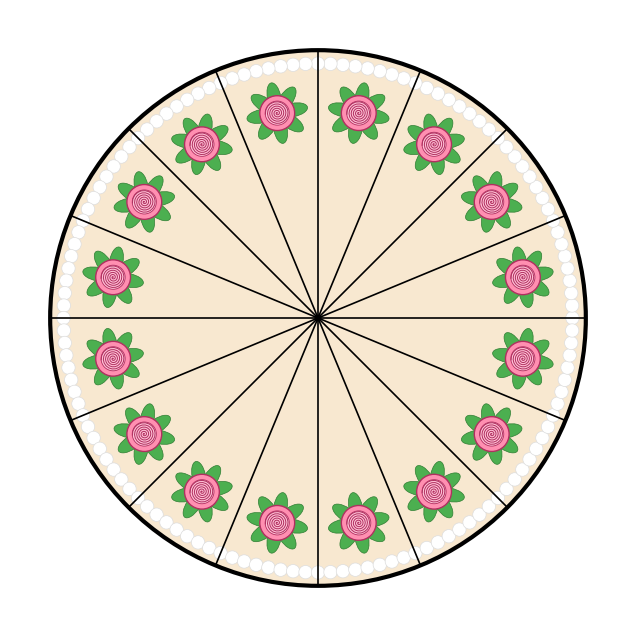

In [5]:
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Ellipse

 # ==========================================
 # Einstellungen
 # ==========================================

NUM_SLICES = 16 # Anzahl der Tortenstücke
NUM_LEAVES = 8  # Anzahl der Blätter an den Röschen
RADIUS = 1.0

def zeichne_torte(
    num_slices=15,
    num_leaves=8,
    radius=1.0,
    figsize=(8, 8),
):
    """Zeichnet eine runde Torte mit num_slices gleich großen Stücken."""
    rose_radius = 0.78 * radius
    rose_size_in = 0.045 * radius
    rose_size_out = 0.065 * radius
    border_radius = 0.95 * radius
    line_width = 1.2
    # ==========================================
    # Zeichenfläche
    # ==========================================

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_aspect("equal")
    ax.set_xlim(-1.15, 1.15)
    ax.set_ylim(-1.15, 1.15)
    ax.axis("off")

    # Hintergrund
    fig.patch.set_facecolor("white")

    # ==========================================
    # Tortenboden
    # ==========================================
    cake = Circle(
        (0,0),
        radius,
        facecolor="#F8E8D0",
        edgecolor="black",
        linewidth=3
    )

    ax.add_patch(cake)

    # ==========================================
    # Zuckerrand
    # ==========================================
    for i in range(num_slices*8):
        a = math.radians(i * 360 / (num_slices*8))
        x = border_radius*math.cos(a)
        y = border_radius*math.sin(a)

        ax.add_patch(
            Circle(
                (x,y),
                0.025,
                facecolor="white",
                edgecolor="#DDDDDD",
                linewidth=0.5
            )
        )

    # ==========================================
    # Schnitte
    # ==========================================
    for i in range(num_slices):
        angle = math.radians(i * 360 / num_slices)
        x = RADIUS * math.cos(angle)
        y = RADIUS * math.sin(angle)

        ax.plot(
            [0,x],
            [0,y],
            color="black",
            linewidth=line_width
        )

    # Mittelpunkt
    ax.add_patch(
        Circle(
            (0,0),
            0.01,
            color="black"
        )
    )

    # ==========================================
    # Röschen
    # ==========================================
    rose_radius = 0.78

    for i in range(num_slices):

        angle = math.radians((i+0.5) * 360 / num_slices)
        x = rose_radius * math.cos(angle)
        y = rose_radius * math.sin(angle)

        # Blätter
        for l in range (num_leaves):

            offset = math.radians(l * 360 / num_leaves)
            a = angle + offset
            lx = x + 0.06*math.cos(a)
            ly = y + 0.06*math.sin(a)

            leaf = Ellipse(
                (lx,ly),
                width=0.11,
                height=0.05,
                angle=math.degrees(a),
                facecolor="#4CAF50",
                edgecolor="#2E7D32",
                linewidth=0.5
            )

            ax.add_patch(leaf)

        # Rose außen
        ax.add_patch(
            Circle(
                (x,y),
                rose_size_out,
                facecolor="#FF8FB1",
                edgecolor="#B03060",
                linewidth=1
            )
        )

        # Rose innen
        ax.add_patch(
            Circle(
                (x,y),
                rose_size_in,
                facecolor="#FFC0D5",
                edgecolor="#B03060",
                linewidth=0.6
            )
        )

        # Spirale
        xs=[]
        ys=[]
        for t in range(100):
            r=rose_size_in*t/100
            phi=t*0.35
            xs.append(x+r*math.cos(phi))
            ys.append(y+r*math.sin(phi))

        ax.plot(xs,ys,color="#B03060",linewidth=0.7)

    return fig, ax


if __name__ == "__main__":

    # ==========================================
    # Anzeigen
    # ==========================================
    zeichne_torte(NUM_SLICES, NUM_LEAVES, RADIUS)
    plt.show()


